<h1>FFNN From Scratch</h1>
<h2>Weight Initializer Analysis</h2>

<h3>Configure Root</h3>

In [28]:
import sys
from pathlib import Path as path

root = path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))


<h3>Import Library</h3>

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
from src.model.layers      import FFNN
from src.model.optimizer   import GradientDescent
from src.utils.data_loader import DataLoader
from src.utils.visualization import Visualizer


<h3>Importing Data</h3>

In [30]:
loader = DataLoader('../data/datasetml_2026.csv')
loader.load()
loader.eda()
loader.split(train_ratio=0.8, random_seed=42)
loader.preprocess()
loader.split_val(val_size=0.2, random_state=42)

X_train, y_train = loader.get_train()
X_val,   y_val   = loader.get_val()
X_test,  y_test  = loader.get_test()

X_train = np.asarray(X_train, dtype=np.float64)
X_val   = np.asarray(X_val,   dtype=np.float64)
X_test  = np.asarray(X_test,  dtype=np.float64)
y_train = np.asarray(y_train, dtype=np.float64)
y_val   = np.asarray(y_val,   dtype=np.float64)
y_test  = np.asarray(y_test,  dtype=np.float64)

INPUT_DIM = X_train.shape[1]
print(f'Input dim: {INPUT_DIM}')
print(f'Train: {X_train.shape}')
print(f'Val:   {X_val.shape}')
print(f'Test:  {X_test.shape}')


[DataLoader] Berhasil memuat 10000 baris dan 12 kolom dari '../data/datasetml_2026.csv'

[DataLoader] Kolom: ['cgpa', 'backlogs', 'college_tier', 'country', 'university_ranking_band', 'internship_count', 'aptitude_score', 'communication_score', 'specialization', 'industry', 'internship_quality_score', 'placement_status']

                          Head Dataset                           


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed



                      Datatypes Dataset===                       
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 9

None


                     Informasi Missing Data                      


...

np.int64(0)


                  Informasi Outlier (Metode IQR                  
cgpa: 83 outliers
backlogs: 29 outliers
internship_count: 662 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 36 outliers

                   Informasi Distribusi Target                   


placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64

placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64

[DataLoader] Data di-split: 8000 Train, 2000 Test



               Informasi Outlier Setelah Clipping                
cgpa: 0 outliers
backlogs: 0 outliers
internship_count: 0 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 0 outliers
[DataLoader] Preprocessing selesai.
[DataLoader] X_train : (6400, 21) | y_train : (6400,)
[DataLoader] X_val   : (1600, 21)   | y_val   : (1600,)
Input dim: 21
Train: (6400, 21)
Val:   (1600, 21)
Test:  (2000, 21)


<h3>Initialize Model</h3>

In [31]:
HIDDEN_DIM        = [256, 128, 64]
EPOCHS            = 50
BATCH_SIZE        = 32
LR                = 0.01
HIDDEN_ACTIVATION = 'relu'
OUTPUT_ACTIVATION = 'sigmoid'
LOSS_NAME         = 'bce'
SEED              = 42

ARCH = dict(
    input_dim         = INPUT_DIM,
    hidden_dim        = HIDDEN_DIM,
    output_dim        = 1,
    hidden_activation = HIDDEN_ACTIVATION,
    output_activation = OUTPUT_ACTIVATION,
    loss_name         = LOSS_NAME,
    seed              = SEED,
)

model0 = FFNN(**ARCH, init_method='zero')
model1 = FFNN(**ARCH, init_method='uniform')
model2 = FFNN(**ARCH, init_method='normal')
model3 = FFNN(**ARCH, init_method='xavier')
model4 = FFNN(**ARCH, init_method='he')


[FFNN] architecture initialized with: 21 -> 256 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: zero, seed=42
[FFNN] architecture initialized with: 21 -> 256 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: uniform, seed=42
[FFNN] architecture initialized with: 21 -> 256 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: normal, seed=42
[FFNN] architecture initialized with: 21 -> 256 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: xavier, seed=42
[FFNN] architecture initialized with: 21 -> 256 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: he, seed=42


<h3>Train Models</h3>

In [32]:
# Setiap model mendapat optimizer-nya sendiri
optimizer0 = GradientDescent(lr=LR, reg_type='l2', lam=1e-3)
optimizer1 = GradientDescent(lr=LR, reg_type='l2', lam=1e-3)
optimizer2 = GradientDescent(lr=LR, reg_type='l2', lam=1e-3)
optimizer3 = GradientDescent(lr=LR, reg_type='l2', lam=1e-3)
optimizer4 = GradientDescent(lr=LR, reg_type='l2', lam=1e-3)
viz = Visualizer()

models = [
    ('Zero',    model0, optimizer0),
    ('Uniform', model1, optimizer1),
    ('Normal',  model2, optimizer2),
    ('Xavier',  model3, optimizer3),
    ('He',      model4, optimizer4),
]

for name, model, optimizer in models:
    viz.print_section_term(f'Training {name}')
    for epoch in range(1, EPOCHS + 1):
        metrics = model.train_epoch(
            X_train, y_train,
            optimizer  = optimizer,
            batch_size = BATCH_SIZE,
            x_val      = X_val,
            y_val      = y_val,
        )
        print(f"Epoch {epoch:03d}/{EPOCHS} "
              f"Train loss: {metrics['train_loss']:.4f}, acc: {metrics['train_acc']:.4f} "
              f"Val loss: {metrics['val_loss']:.4f}, acc: {metrics['val_acc']:.4f}")



                          Training Zero                          
Epoch 001/50 Train loss: 0.6832, acc: 0.6164 Val loss: 0.6759, acc: 0.6162
Epoch 002/50 Train loss: 0.6723, acc: 0.6164 Val loss: 0.6697, acc: 0.6162
Epoch 003/50 Train loss: 0.6684, acc: 0.6164 Val loss: 0.6675, acc: 0.6162
Epoch 004/50 Train loss: 0.6669, acc: 0.6164 Val loss: 0.6665, acc: 0.6162
Epoch 005/50 Train loss: 0.6662, acc: 0.6164 Val loss: 0.6661, acc: 0.6162
Epoch 006/50 Train loss: 0.6660, acc: 0.6164 Val loss: 0.6660, acc: 0.6162
Epoch 007/50 Train loss: 0.6659, acc: 0.6164 Val loss: 0.6659, acc: 0.6162
Epoch 008/50 Train loss: 0.6658, acc: 0.6164 Val loss: 0.6659, acc: 0.6162
Epoch 009/50 Train loss: 0.6658, acc: 0.6164 Val loss: 0.6659, acc: 0.6162
Epoch 010/50 Train loss: 0.6658, acc: 0.6164 Val loss: 0.6659, acc: 0.6162
Epoch 011/50 Train loss: 0.6658, acc: 0.6164 Val loss: 0.6659, acc: 0.6162
Epoch 012/50 Train loss: 0.6658, acc: 0.6164 Val loss: 0.6659, acc: 0.6162
Epoch 013/50 Train loss: 0.6658, 

C:\Users\ASUS\Documents\GitHub\FFNN-Scratch\src\model\activations.py:21: RuntimeWarning: overflow encountered in exp
  return 1/ (1 + np.exp(-x))


Epoch 001/50 Train loss: 13.6039, acc: 0.6725 Val loss: 11.0094, acc: 0.6800
Epoch 002/50 Train loss: 11.7253, acc: 0.7013 Val loss: 9.5601, acc: 0.7212
Epoch 003/50 Train loss: 10.4837, acc: 0.7120 Val loss: 9.0591, acc: 0.7369
Epoch 004/50 Train loss: 11.3209, acc: 0.6625 Val loss: 11.2038, acc: 0.6756
Epoch 005/50 Train loss: 12.1734, acc: 0.6891 Val loss: 10.1766, acc: 0.7044
Epoch 006/50 Train loss: 10.5288, acc: 0.7036 Val loss: 9.4357, acc: 0.7250
Epoch 007/50 Train loss: 10.6550, acc: 0.7169 Val loss: 9.0122, acc: 0.7388
Epoch 008/50 Train loss: 9.9066, acc: 0.7300 Val loss: 8.4461, acc: 0.7550
Epoch 009/50 Train loss: 9.5604, acc: 0.7280 Val loss: 8.8234, acc: 0.7444
Epoch 010/50 Train loss: 9.4469, acc: 0.7411 Val loss: 8.3314, acc: 0.7575
Epoch 011/50 Train loss: 10.2186, acc: 0.6525 Val loss: 11.8224, acc: 0.6575
Epoch 012/50 Train loss: 10.1177, acc: 0.6842 Val loss: 10.6630, acc: 0.6906
Epoch 013/50 Train loss: 9.7514, acc: 0.7273 Val loss: 8.7521, acc: 0.7462
Epoch 014/5

<h3>Plot Visualization</h3>


                       Loss Curve — Normal                       
[Visualizer] saved in ../results/initializer_unstable_loss.png


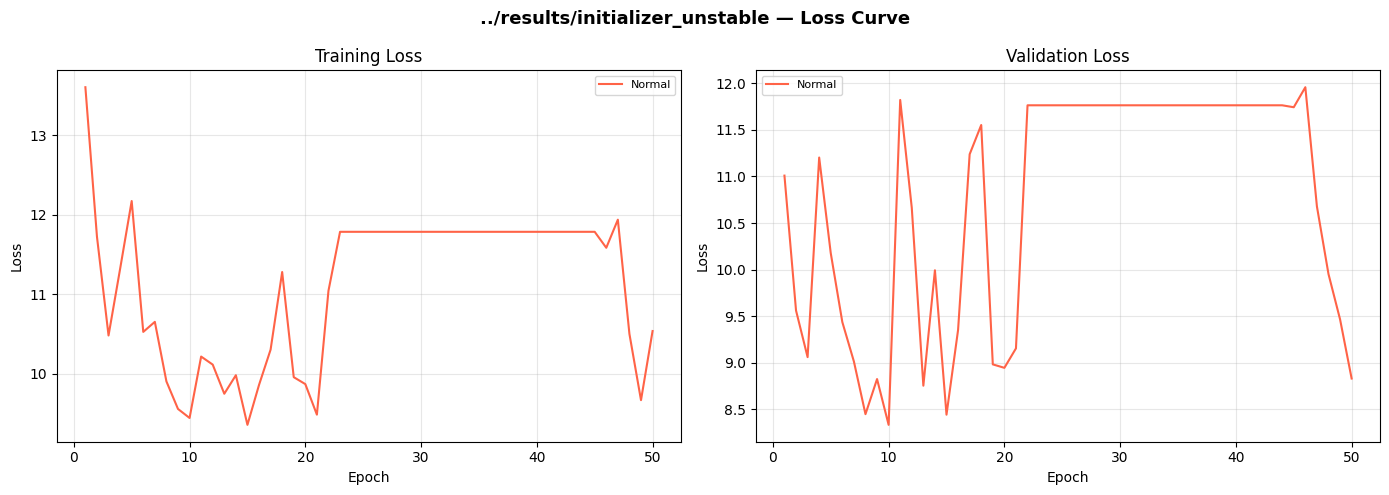


             Loss Curve — Zero, Uniform, Xavier, He              
[Visualizer] saved in ../results/initializer_stable_loss.png


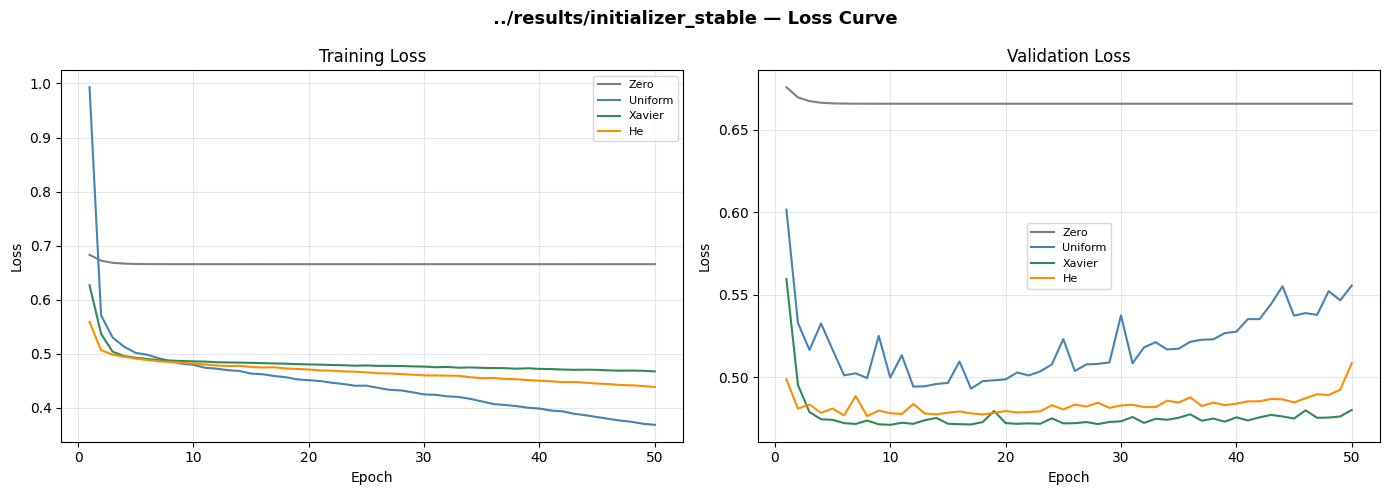


             Weight Distribution — All Initializers              
[Visualizer] saved in ../results/initializer_comparison_weights.png


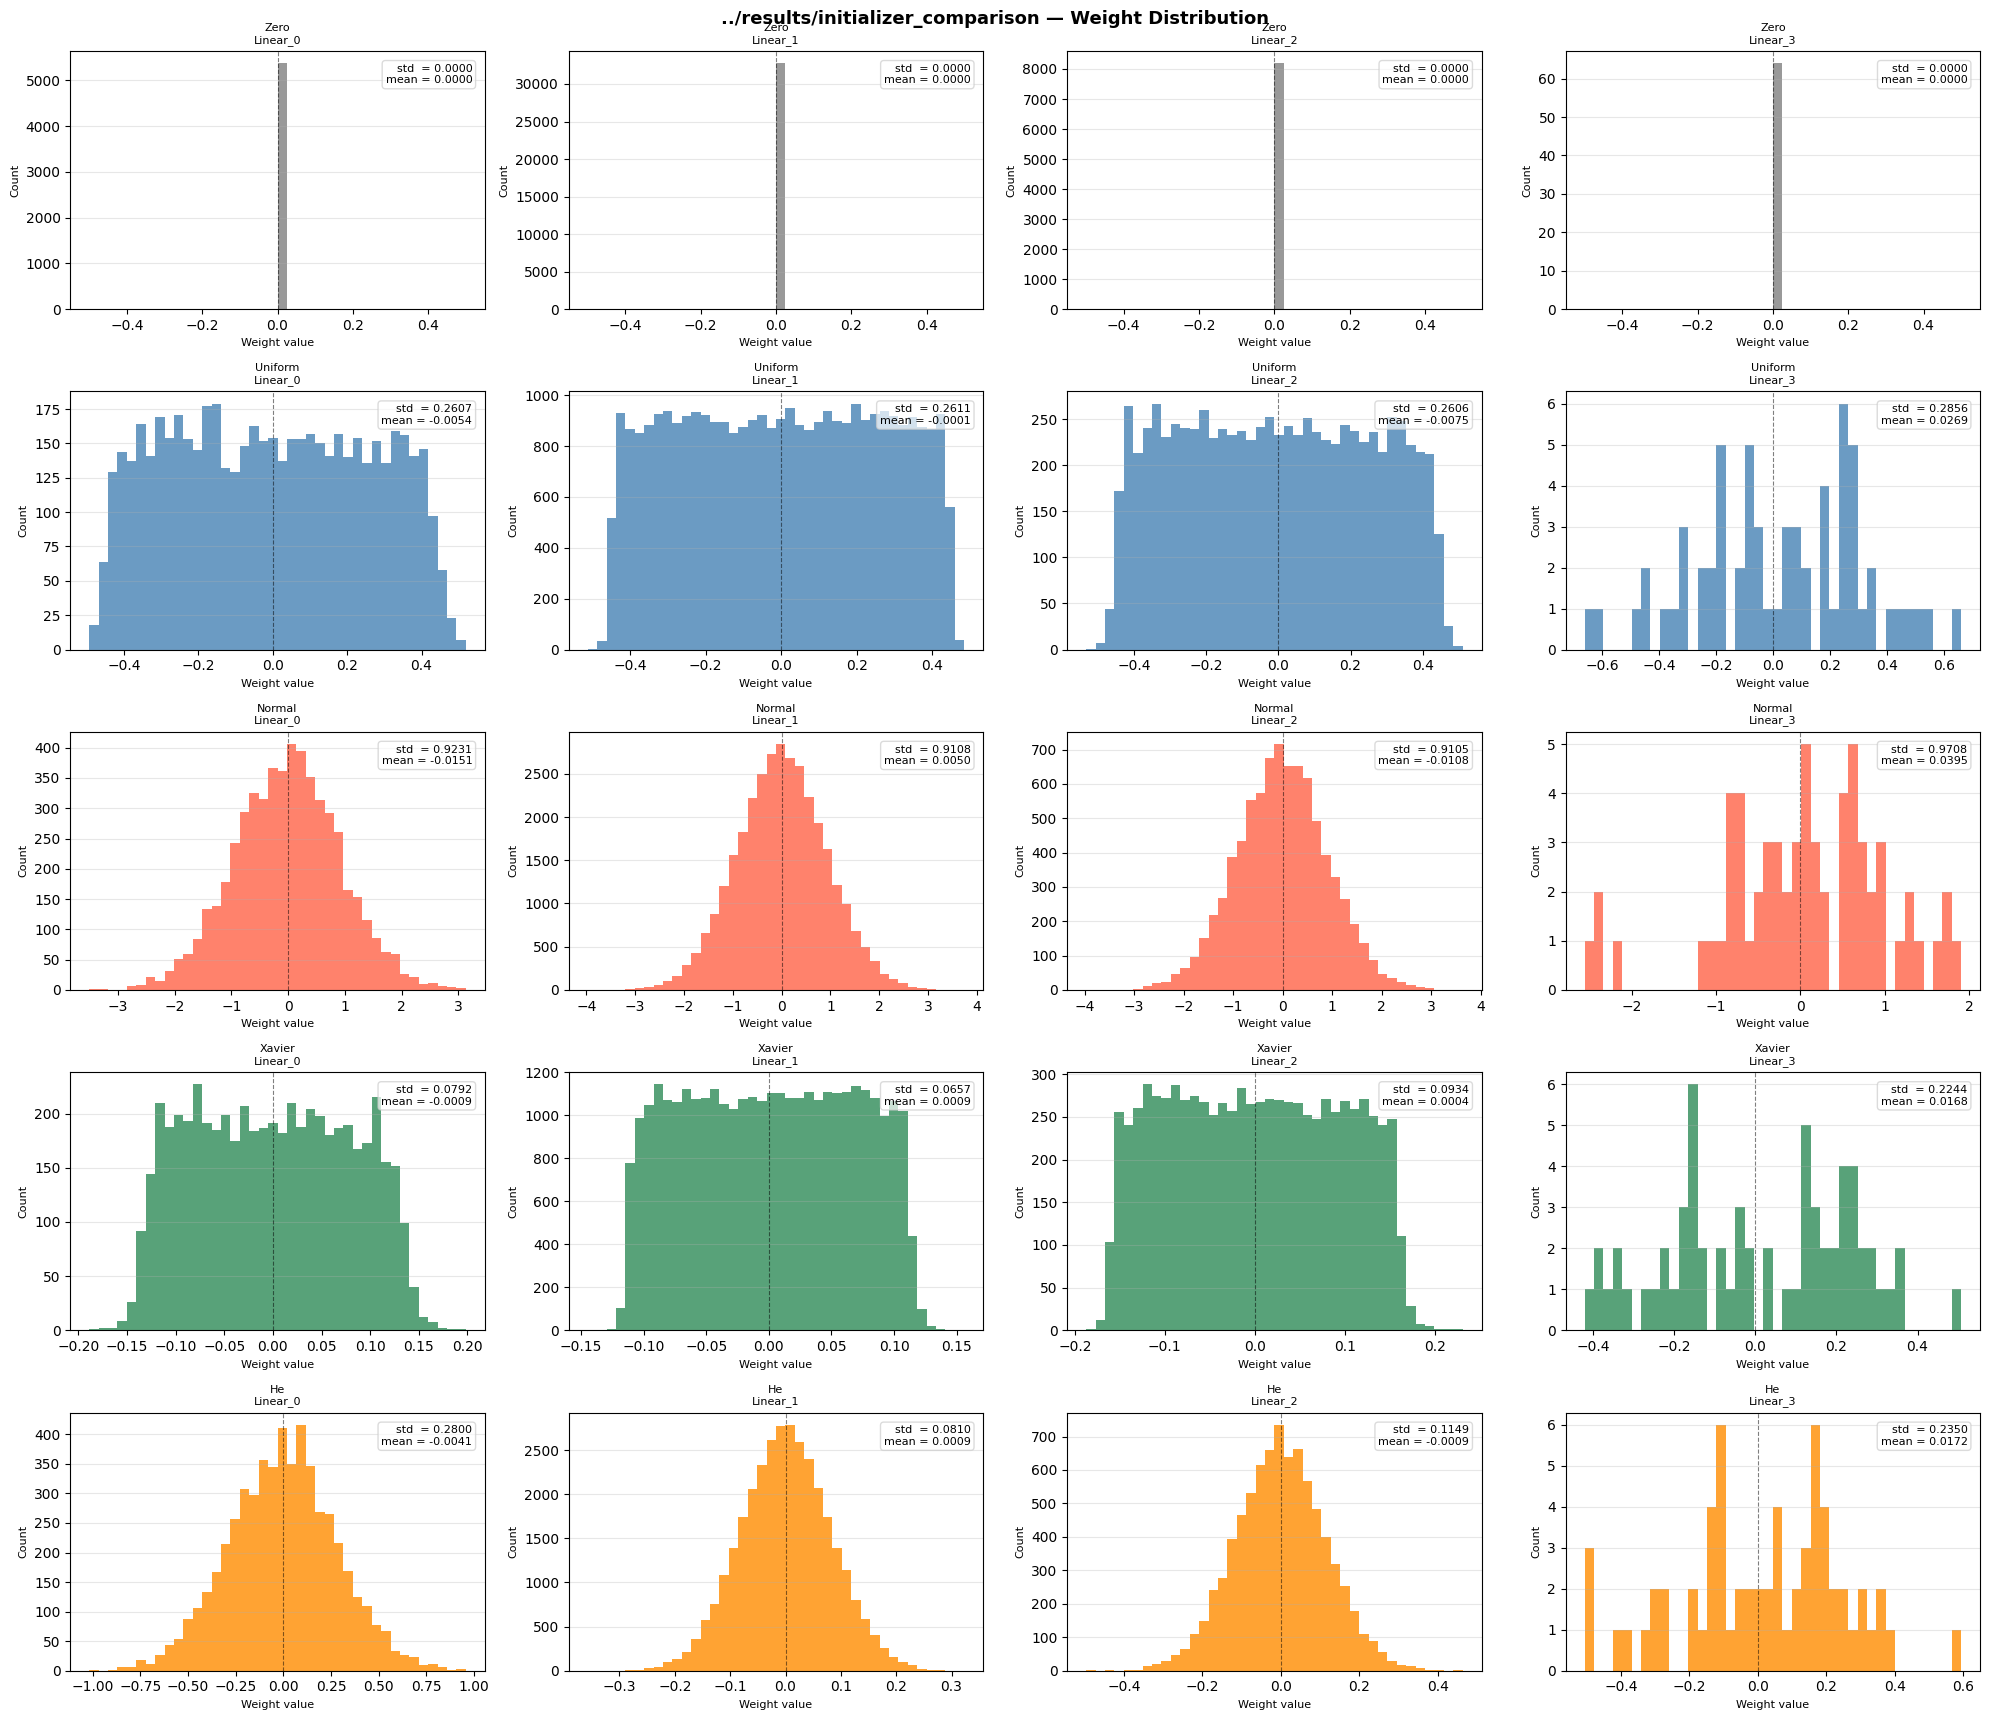


            Gradient Distribution — All Initializers             
[Visualizer] saved in ../results/initializer_comparison_grads.png


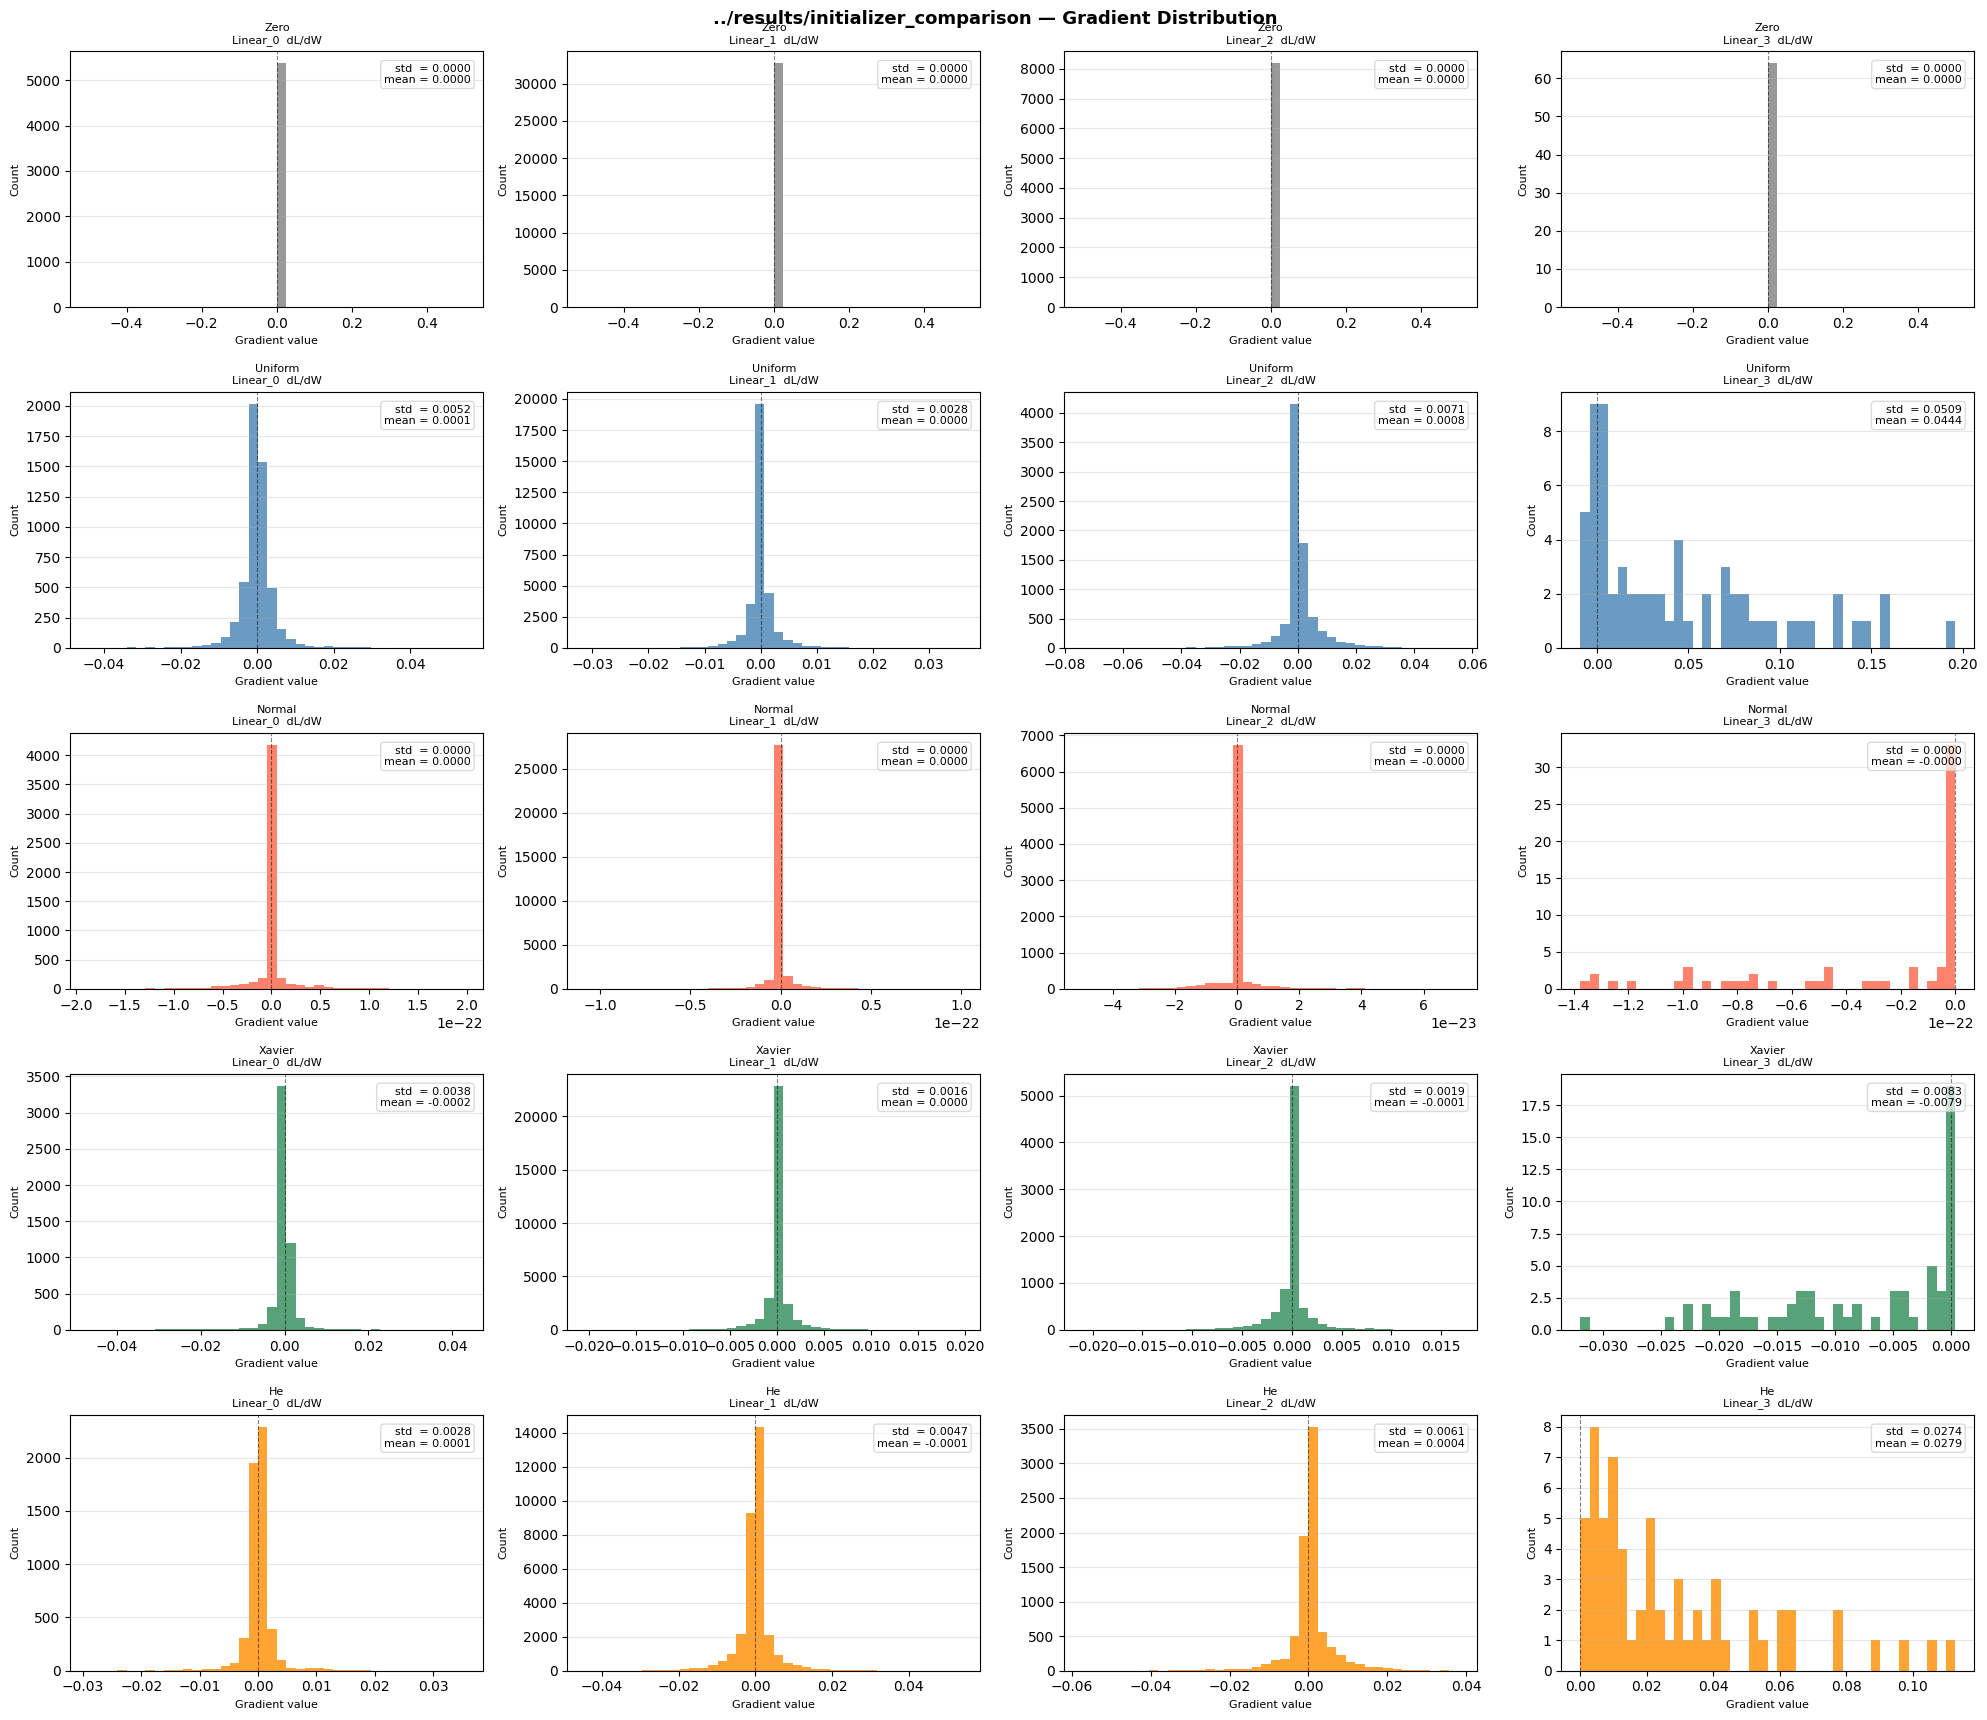


                       Final Test Accuracy                       
Initializer  | Accuracy
-------------------------
Zero         |   0.6110
Uniform      |   0.7150
Normal       |   0.7020
Xavier       |   0.7365
He           |   0.7310


In [35]:
results = {
    'Zero'    : {'history': model0.get_training_history(), 'model': model0, 'color': 'gray'},
    'Uniform' : {'history': model1.get_training_history(), 'model': model1, 'color': 'steelblue'},
    'Normal'  : {'history': model2.get_training_history(), 'model': model2, 'color': 'tomato'},
    'Xavier'  : {'history': model3.get_training_history(), 'model': model3, 'color': 'seagreen'},
    'He'      : {'history': model4.get_training_history(), 'model': model4, 'color': 'darkorange'},
}

# Normal (skala loss besar, ditampilkan terpisah)
results_unstable = {k: results[k] for k in ['Normal']}

#  Uniform, Xavier, He (skala loss normal ~0.5)
results_stable = {k: results[k] for k in ['Zero', 'Uniform', 'Xavier', 'He']}

viz.print_section_term('Loss Curve — Normal')
viz.plot_comparison(
    results=results_unstable,
    mode='loss',
    save_prefix='../results/initializer_unstable'
)

viz.print_section_term('Loss Curve — Zero, Uniform, Xavier, He')
viz.plot_comparison(
    results=results_stable,
    mode='loss',
    save_prefix='../results/initializer_stable'
)

viz.print_section_term('Weight Distribution — All Initializers')
viz.plot_comparison(
    results=results,
    mode='weights',
    save_prefix='../results/initializer_comparison'
)

viz.print_section_term('Gradient Distribution — All Initializers')
viz.plot_comparison(
    results=results,
    mode='grads',
    save_prefix='../results/initializer_comparison',
    x_ref=X_val,
    y_ref=y_val
)

viz.print_section_term('Final Test Accuracy')
print(f"{'Initializer':<12} | {'Accuracy':>8}")
print('-' * 25)
for name, r in results.items():
    y_pred = r['model'].predict(X_test)
    acc = float((y_pred == y_test).mean())
    print(f'{name:<12} | {acc:>8.4f}')


<h3>Save Models</h3>

In [34]:
os.makedirs('../output', exist_ok=True)

for name, r in results.items():
    fname = name.lower()
    r['model'].save(f'../output/{fname}_initializer')


[FFNN] Model tersimpan di '../output/zero_initializer' 
[FFNN] Model tersimpan di '../output/uniform_initializer' 
[FFNN] Model tersimpan di '../output/normal_initializer' 
[FFNN] Model tersimpan di '../output/xavier_initializer' 
[FFNN] Model tersimpan di '../output/he_initializer' 
